IA & Data science (LU3IN0226) -- 2025-2026
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut, Maxellende Julienne.*


# Projet final

<font size="+1" color="RED">**[Q]**</font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

*Mehdi Qostali et Hakim Ziane*

Ce projet peut être fait en binôme ou tout seul.

**Le nom de chaque membre du binôme doit être indiqué dans la boîte ci-dessus**.


**Le compte-rendu est soumis sur la page Moodle.

Si vous êtes en binôme : **<u>un seul rendu doit être remis sur un seul des deux comptes du binôme</u>**.

Les groupes de plus de 2 personnes ne sont pas autorisés.

**La dernière séance de TD-TME11 de votre groupe sera réservée pour travailler sur ce mini-projet.**

<font color="RED" size="+1"><b>[Q]</b></font> **Renommer ce notebook**

**Nom à donner au fichier à poster** : *projet-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme

Voir ci-dessous ce qui est à remettre.



# Projet - mai 2026

<b>Date de remise du compte-rendu : <font size="+1" color="RED">au plus tard le lundi 1er juin 2026, avant 10h</font></b>.
    
<b>Attention!</b> le site Moodle ferme à 20h pile (heure du site Moodle)! prévoyez de vous y connecter au moins 15mn avant la fermeture...
<b>Il n'y aura pas de prolongation possible.</b>

## Travail à faire

Vous devez compléter ce notebook en rajoutant vos expérimentations avec vos algorithmes d'apprentissage (supervisé et non-supervisé) sur les données Fashion MNIST fournies (voir plus loin).

Vous devez appliquer les algorithmes d'apprentissage vus en cours et réaliser une analyse sur les données afin de mettre en évidence des résultats intéressants.

Les données seront chargées par les commandes de chargement des données fournies dans ce notebook (ci-dessous).
Dans le notebook que vous rendrez, le chargement des fichiers de données doit considérer cette arborescence.


## Remarque: utilisation d'IA générative 

Toute utilisation d'une IA générative (ChatGPT, Mistral, Claude,...) pour réaliser certains traitements de ce projet doit **obligatoirement** être indiqué dans votre notebook. De plus, si vous utilisez une telle IA générative, vous devez pouvoir être capable d'expliquer ce qu'elle vous a fourni et que vous avez utilisé.

## Compte-rendu demandé
Ce qui doit être remis avant la date limite : un unique fichier archive compressé (`.tgz`, ou `.zip` uniquement) de nom :
`projet-Nom1_Nom2.tgz` ou `projet-Nom1_Nom2.zip` contenant:
- ce **notebook** complété (et avec vos noms !). Il doit pouvoir être exécuté sans autre apport (pensez à vous en assurer avant de le rendre). 
- votre **librairie iads** complète, c'est à dire votre répertoire `iads/` contenant tous les fichiers python complets.
- un **poster** sous la forme d'un fichier PDF dont le nom est de la forme: *tme11-Nom1_Nom2.pdf* qui correspond à un poster décrivant l'ensemble des expérimentations menées et les résultats obtenus.


**Très important** : les fichiers dans l'archive doivent être placés de façon à respecter la structure de fichiers suivante :

          --projet-Nom1_Nom2/
              --iads/
                  -- Classifiers.py
                  -- etc.
              -- Projet/
                  --  projet-Nom1_Nom2.ipynb


<b>Remarque</b>: 
- **Les <u>fichiers de données ne doivent pas être inclus dans votre archive</u>** ! 
- Pensez à vérifier que votre archive contient bien tous les fichiers demandés et **seulement** les fichiers demandés.
- **Tous les fichiers demandés doivent être soumis avant la date limite**, en une seule archive comme indiqué ci-dessus.

## Soutenance des projets
**Les soutenances auront lieu le <font size="+1" color="RED">mardi 2 juin 2026</font>, à partir de 14h**. 

Un ordre de passage ainsi que la salle de TME où elles auront lieu seront affichées sur le Moodle la veille (la remise d'un compte-rendu à la date d'échéance indiquée (avant le lundi 1er juin 2026, 10h) est **obligatoire** pour passer une soutenance).

La <b>soutenance est obligatoire</b> : <u>tout projet pour lequel la soutenance n'est pas passée sera noté $0$</u>.

Modalités de la soutenance:
- durée de la soutenance : 10 mn pour un binôme, 7 mn pour un monôme ;
- elle a lieu devant un ordinateur avec le notebook et le poster comme support ;
    - elle commence par une rapide présentation des expérimentations réalisées et résultats obtenus (max. 4 à 5mns)
    - puis elle se poursuit par des questions posées individuellement aux membres du binômes sur les expériences ou le code python réalisé.
- la note de soutenance est individuelle pour chaque membre d'un binôme.



In [1]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
%matplotlib inline  

import math
import time
import sys

# pour les dendrogrammes) :
import scipy


In [2]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as cl

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev

# importation de Clustering 
from iads import Clustering as clust


## Données pour le projet : Fashion MNIST

Les données sont fournies dans l'archive `data.tgz`. 
Cette archive contient 2 fichiers CSV:
- le fichier `fashion-mnist_train.csv`: ce fichier doit servir à l'entraînement de vos modèles, et leur évaluation en validation croisée,
- le fichier `fashion-mnist_test.csv`: ce fichier ne doit être utilisé que pour évaluer un modèle et il ne doit pas servir pour faire mettre au point le modèle.


Une documentation sur ces données peut être consultée sur la <a href="https://fr.wikipedia.org/wiki/Fashion_MNIST" target="NEW">page wikipedia Fashion MNIST</a>.


#### Chargement des données

In [3]:
from pathlib import Path

TRAIN_FILE = 'fashion-mnist_train.csv'
for candidate in (Path('../data'), Path('data')):
    if (candidate / TRAIN_FILE).exists():
        DATA_DIR = candidate
        break
else:
    raise FileNotFoundError(f"Impossible de trouver {TRAIN_FILE} dans ../data ou data")

data_train = pd.read_csv(DATA_DIR / TRAIN_FILE)


In [4]:
from pathlib import Path

TEST_FILE = 'fashion-mnist_test.csv'
for candidate in (Path('../data'), Path('data')):
    if (candidate / TEST_FILE).exists():
        DATA_DIR = candidate
        break
else:
    raise FileNotFoundError(f"Impossible de trouver {TEST_FILE} dans ../data ou data")

data_test = pd.read_csv(DATA_DIR / TEST_FILE)


In [5]:
data_train.shape

(60000, 785)

In [6]:
data_test.shape

(10000, 785)

## Tâches à réaliser

### Apprentissage supervisé

*Tâches*: évaluation d'algorithmes et de représentations des données.
- classification binaire
- classification multi-classe

*Etudes suggérées*:
- différents classifiers:
    - perceptron et variantes
    - k-plus proches voisins 
    - arbres de décision
    - ensembles de classifieurs
- analyse des résultats: comparaison des approches et de leurs hyper-paramètres
    - accuracy, temps d'exécutions
    - score fold par fold
    - matrice de confusion
    - ...


### Apprentissage non-supervisé

*Tâche*: présence éventuelle de groupes de données: groupes intra-classes, et/ou groupes interclasses.

*Etudes possibles*:
- étudier l'application d'un clustering hiérarchique et son résultat;
- étudier les résultats de l'application de l'algorithme des k-moyennes, pour différentes valeurs de k: roposer des évaluations des clusters trouvés afin de mettre en évidence les plus intéressants:
    - en utilisant les indices d'évaluation présentés en cours;
    - en comparant par diverses méthodes les clusters trouvés avec les vrais labels des classes (targets y).
- proposer une visualisation des résultats obtenus
- analyse des exemples mal-classés: est-ce qu'ils forment un (ou des) sous-groupes?
- ...


   


## Poster à rendre dans le compte-rendu (format PDF)

Votre poster doit décrire de façon synthétique **l'ensemble des expérimentations** menées sur les données, les résultats obtenus en apprentissage supervisé et en apprentissage non-supervisé ainsi que les conclusions/bilans que vous tirez de ces expérimentations (ie. ce que vous avez appris sur ces données).

**Important*: vous devez indiquer vos noms/prénoms sur le poster.


# Votre travail commence à partir d'ici 

## Note sur l'utilisation de l'IA générative

L'utilisation de ChatGPT/Codex a servi à la correction pour d'imports, l'ajout de commentaires explicatifs, l'orthographe et les fautes de code. Les choix expérimentaux restent explicites dans le notebook : échantillonnage stratifié, validation croisée, évaluation sur le jeu de test officiel et mesures de clustering.

## 1. Préparation et exploration des données

Les fichiers Fashion-MNIST contiennent une colonne `label` et 784 colonnes de pixels. On sépare les labels des pixels, puis on normalise les pixels dans `[0, 1]`. Cette normalisation est importante pour les méthodes basées sur des distances ou des gradients.

In [7]:
from IPython.display import display

# Importe KMeans pour appliquer l'algorithme des k-moyennes.
from sklearn.cluster import KMeans

# Importe PCA pour réduire la dimension des images avant le clustering.
from sklearn.decomposition import PCA

# Importe deux métriques pour comparer les clusters aux vraies classes.
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Importe les outils du clustering hiérarchique : dendrogramme, découpe et linkage.
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage

# Fixe la graine aléatoire pour rendre les expériences reproductibles.
RANDOM_STATE = 42

# Sépare les pixels X_train et les labels y_train du jeu d'entraînement et du jeu de test.
X_train, y_train = ut.split_features_labels(data_train)
X_test, y_test = ut.split_features_labels(data_test)

# Crée la liste des labels numériques des 10 classes : 0, 1, ..., 9.
labels = list(range(10))

# Convertit les labels numériques en noms lisibles, par exemple 0 -> T-shirt/top.
class_names = [ut.CLASS_NAMES[i] for i in labels]

# Affiche les dimensions des matrices de pixels train et test.
print("train:", X_train.shape, "test:", X_test.shape)

# Calcule le nombre d'exemples de chaque classe dans le jeu d'entraînement.
distribution_train = ut.class_distribution(y_train)

# Calcule le nombre d'exemples de chaque classe dans le jeu de test.
distribution_test = ut.class_distribution(y_test)

# Affiche le tableau de répartition des classes du jeu d'entraînement.
display(distribution_train)


train: (60000, 784) test: (10000, 784)


,classe,nom,effectif
0,0,T-shirt/top,6000
1,1,Trouser,6000
2,2,Pullover,6000
3,3,Dress,6000
4,4,Coat,6000
5,5,Sandal,6000
6,6,Shirt,6000
7,7,Sneaker,6000
8,8,Bag,6000
9,9,Ankle boot,6000


**Lecture du tableau de répartition des classes**  
Le tableau indique, pour chaque label, le nom de la classe et le nombre d'images dans le jeu d'entraînement. Chaque classe contient `6000` images, donc le jeu d'entraînement est équilibré.

Cet équilibre est important pour l'évaluation : une accuracy élevée ne vient pas simplement du fait qu'une classe serait beaucoup plus fréquente que les autres. La baseline multi-classe est donc proche de `0.10`, car il y a 10 classes.

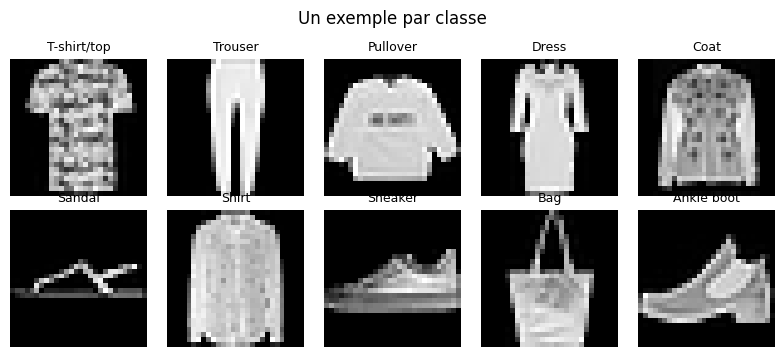

In [8]:
# Objectif : afficher une image représentative de chaque classe Fashion-MNIST.
# Crée une liste vide qui contiendra les indices des images à afficher.
indices = []

for label in labels:
    # Cherche tous les indices dont la vraie classe vaut label, puis garde le premier.
    indices.append(np.where(y_train == label)[0][0])

# Affiche les images sélectionnées dans une grille de 5 colonnes.
ut.plot_images_grid(X_train, y_train, indices=indices, n_cols=5, title="Un exemple par classe")

# Affiche concrètement la figure Matplotlib dans le notebook.
plt.show()

**Lecture du graphe d'exemples par classe**  
Ce graphe affiche une image représentative de chaque classe Fashion-MNIST. Les images sont en niveaux de gris et ont une résolution de `28 x 28` pixels.

On voit que certaines classes sont visuellement très différentes, comme `Trouser`, `Sandal`, `Bag` ou `Ankle boot`. D'autres sont plus proches, surtout les vêtements du haut : `T-shirt/top`, `Pullover`, `Coat` et `Shirt`. Cette proximité explique pourquoi les modèles feront davantage d'erreurs entre ces catégories.

## 2. Apprentissage supervisé : classification binaire

On commence par une tâche binaire volontairement difficile : distinguer les classes `0` (*T-shirt/top*) et `6` (*Shirt*). Ces deux catégories sont visuellement proches, donc elles constituent un bon test pour comparer les classifieurs.

In [9]:
# Crée le jeu d'entraînement binaire avec seulement classes 0 et 6.
# La fonction transforme ensuite les labels en 0 et 1.
X_bin_train, y_bin_train = ut.binary_subset(X_train, y_train, 0, 6)

# Crée le jeu de test binaire avec les mêmes deux classes.
# Cela permet d'évaluer le modèle final sur T-shirt/top vs Shirt.
X_bin_test, y_bin_test = ut.binary_subset(X_test, y_test, 0, 6)

# Crée un sous-échantillon stratifié de 4000 exemples pour la validation croisée.
# Stratifié signifie que les proportions des deux classes sont conservées.
# Cela réduit le temps de calcul tout en gardant un échantillon représentatif.
X_bin_cv, y_bin_cv = ut.stratified_sample(X_bin_train, y_bin_train, 4000, RANDOM_STATE)

# Prépare les classifieurs à comparer sur la tâche binaire.
# Chaque clé est le nom affiché dans le tableau de résultats.
# Chaque valeur est un modèle construit dans iads/Classifiers.py.
binary_classifiers = {
    # Modèle de référence : prédit toujours la classe majoritaire.
    "baseline": cl.baseline_classifier(),

    # Perceptron : modèle linéaire simple.
    "perceptron": cl.perceptron_classifier(RANDOM_STATE),

    # k plus proches voisins avec k=5.
    "kNN k=5": cl.knn_classifier(5),

    # Arbre de décision limité à une profondeur maximale de 12.
    "arbre": cl.decision_tree_classifier(RANDOM_STATE, max_depth=12),

    # Forêt aléatoire composée de 80 arbres.
    "forêt": cl.random_forest_classifier(RANDOM_STATE, n_estimators=80),
}

# Lance la validation croisée à 3 folds sur les modèles définis au-dessus.
# Pour chaque modèle, on obtient les scores fold par fold, la moyenne,
# l'écart type et le temps total.
binary_cv = ev.cross_validate_classifiers(
    binary_classifiers, X_bin_cv, y_bin_cv, cv=3, random_state=RANDOM_STATE
)

display(binary_cv)

,modèle,accuracy_moyenne,accuracy_écart_type,temps_total_s,scores_folds
4,forêt,0.841999,0.013555,3.847527,"[0.8441, 0.8245, 0.8575]"
2,kNN k=5,0.828249,0.010040,2.764623,"[0.8313, 0.8147, 0.8387]"
1,perceptron,0.800751,0.002501,0.413358,"[0.7984, 0.8042, 0.7997]"
3,arbre,0.790000,0.004288,5.019195,"[0.7901, 0.7847, 0.7952]"
0,baseline,0.499750,0.000177,0.025782,"[0.5, 0.4996, 0.4996]"


**Lecture du tableau de validation croisée binaire**  
Chaque ligne correspond à un classifieur testé sur la tâche `T-shirt/top` contre `Shirt`. `accuracy_moyenne` est la moyenne des scores sur les trois folds, `accuracy_écart_type` indique la variation entre les folds, `temps_total_s` donne le temps total et `scores_folds` détaille les trois scores.

La forêt aléatoire obtient le meilleur résultat avec environ `0.842` d'accuracy moyenne. Le kNN est proche avec environ `0.828`. Le perceptron et l'arbre seul sont moins bons. La baseline est à environ `0.50`, ce qui est normal pour deux classes équilibrées.

In [10]:
# Évalue le meilleur modèle binaire sur le vrai jeu de test.
# Donc, on utilise une forêt aléatoire avec 120 arbres.
binary_result = ev.fit_and_score(
    # Crée le modèle de forêt aléatoire.
    cl.random_forest_classifier(RANDOM_STATE, n_estimators=120),

    # Données d'entraînement binaires : seulement T-shirt/top et Shirt.
    X_bin_train,

    # Labels d'entraînement binaires : 0 ou 1.
    y_bin_train,

    # Données de test binaires.
    X_bin_test,

    # Labels réels du test binaire.
    y_bin_test,
)


# Affiche l'accuracy obtenue sur le jeu de test binaire.
# Exemple : 0.8535 signifie environ 85,35 % de bonnes prédictions.
print(f"Accuracy test binaire : {binary_result['accuracy']:.4f}")

# Affiche le temps utilisé pour entraîner le modèle.
print(f"Temps d'apprentissage : {binary_result['fit_time_s']:.2f}s")

# Affiche le temps utilisé pour prédire les classes du jeu de test.
print(f"Temps de prédiction : {binary_result['predict_time_s']:.2f}s")

Accuracy test binaire : 0.8535
Temps d'apprentissage : 11.08s
Temps de prédiction : 0.08s


**Lecture des métriques finales binaires**  
Ces lignes correspondent au résultat de la forêt aléatoire entraînée sur toutes les images d'entraînement des deux classes, puis évaluée sur le fichier `fashion-mnist_test.csv` restreint aux mêmes classes.

L'accuracy de test est d'environ `0.8535`, donc le modèle classe correctement environ 85 images sur 100 entre `T-shirt/top` et `Shirt`. Le temps d'apprentissage est de quelques secondes, et le temps de prédiction est très court.

In [1]:
# Crée la matrice de confusion pour la classification binaire.
binary_confusion = ev.confusion_dataframe(
    # Labels réels du jeu de test binaire.
    y_bin_test,

    # Labels prédits par le modèle sur le jeu de test binaire.
    binary_result["predictions"],

    # Ordre des labels binaires dans la matrice : 0 puis 1.
    labels=[0, 1],

    # Noms affichés à la place de 0 et 1.
    # 0 correspond à T-shirt/top, 1 correspond à Shirt.
    names=["T-shirt/top", "Shirt"],
)

# Les lignes sont les vraies classes.
# Les colonnes sont les classes prédites.
display(binary_confusion)

NameError: name 'ev' is not defined

**Lecture de la matrice de confusion binaire**  
Les lignes correspondent aux vraies classes et les colonnes aux classes prédites. Les cases de la diagonale sont les bonnes prédictions. Les cases hors diagonale sont les erreurs.

Le modèle reconnaît correctement `900` images de `T-shirt/top` et `807` images de `Shirt`. Il confond `100` vrais `T-shirt/top` avec `Shirt`, et `193` vrais `Shirt` avec `T-shirt/top`. La classe `Shirt` est donc plus difficile à reconnaître dans cette expérience.

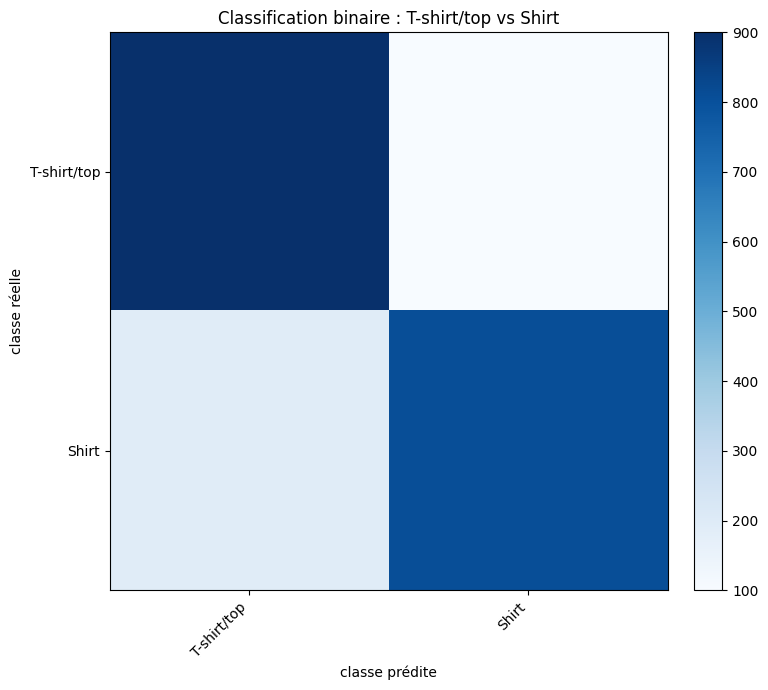

In [12]:
ut.plot_confusion_matrix(
    # Tableau à afficher : lignes = vraies classes, colonnes = classes prédites.
    binary_confusion,
    "Classification binaire : T-shirt/top vs Shirt",
)
# Affiche le graphe dans le notebook.
# Bleu clair = valeur faible ; bleu foncé = valeur élevée.
plt.show()

**Lecture du graphe de matrice de confusion binaire**  
Le graphe représente le même tableau avec une échelle de bleu : une case en bleu clair correspond à peu d'exemples, tandis qu'une case en bleu foncé correspond à beaucoup d'exemples. La diagonale foncée indique les bonnes prédictions, tandis que les cases hors diagonale représentent les confusions.

Le graphe montre que la plupart des exemples sont bien classés, mais aussi que les erreurs ne sont pas symétriques : il y a plus de `Shirt` prédits comme `T-shirt/top` que l'inverse. Cela confirme que la frontière entre ces deux classes est visuellement ambiguë.

**Analyse binaire.** Sur l'échantillon de validation croisée, la forêt aléatoire obtient environ `0.842` d'accuracy moyenne, devant le kNN (`0.828`), le perceptron (`0.801`) et l'arbre seul (`0.790`). Sur le jeu de test officiel restreint aux classes 0 et 6, la forêt aléatoire atteint environ `0.8535`. Les erreurs restantes sont attendues : les deux classes correspondent à des hauts de vêtement de formes proches.

## 3. Apprentissage supervisé : classification multi-classe

On traite maintenant les 10 classes Fashion-MNIST. La comparaison est faite par validation croisée stratifiée sur un sous-ensemble de 5000 exemples, puis le meilleur modèle est entraîné sur 20000 exemples et évalué sur le jeu de test officiel.

In [13]:
# Crée un échantillon équilibré de 5000 images pour la validation croisée.
X_cv, y_cv = ut.stratified_sample(X_train, y_train, 5000, RANDOM_STATE)

# Définit les classifieurs testés pour la classification multi-classe.
multi_classifiers = {
    "baseline": cl.baseline_classifier(),
    "perceptron": cl.perceptron_classifier(RANDOM_STATE),
    "SGD logistique": cl.sgd_logistic_classifier(RANDOM_STATE),
    "kNN k=3": cl.knn_classifier(3),
    "arbre": cl.decision_tree_classifier(RANDOM_STATE, max_depth=18),
    "forêt": cl.random_forest_classifier(RANDOM_STATE, n_estimators=80),
}

# Évalue chaque classifieur avec une validation croisée en 3 parties.
multi_cv = ev.cross_validate_classifiers(
    # Dictionnaire des modèles à comparer.
    multi_classifiers,

    # Données d'entrée de l'échantillon.
    X_cv,

    # Classes réelles de l'échantillon.
    y_cv,

    # Nombre de découpages pour la validation croisée.
    cv=3,

    # Graine aléatoire pour obtenir des résultats reproductibles.
    random_state=RANDOM_STATE,
)

# Affiche le tableau des scores moyens et des temps de calcul.
display(multi_cv)

,modèle,accuracy_moyenne,accuracy_écart_type,temps_total_s,scores_folds
5,forêt,0.834400,0.000802,4.697375,"[0.8338, 0.8338, 0.8355]"
2,SGD logistique,0.802000,0.001351,6.654329,"[0.8032, 0.8026, 0.8001]"
3,kNN k=3,0.790600,0.005762,0.880599,"[0.7966, 0.7828, 0.7923]"
1,perceptron,0.776200,0.003221,4.087512,"[0.7804, 0.7726, 0.7755]"
4,arbre,0.721403,0.009823,7.211176,"[0.7145, 0.7145, 0.7353]"
0,baseline,0.099600,0.000028,0.031914,"[0.0996, 0.0996, 0.0996]"


**Lecture du tableau de validation croisée**  
Chaque ligne correspond à un modèle testé sur les 10 classes. `accuracy_moyenne` est la moyenne des scores obtenus sur les trois folds, `accuracy_écart_type` mesure la stabilité entre les folds, `temps_total_s` donne le temps total de l'expérience et `scores_folds` montre le score de chaque fold.

La forêt aléatoire est le meilleur modèle de cette comparaison avec environ `0.834` d'accuracy moyenne et un écart type très faible. Cela indique un résultat à la fois meilleur et stable. Le modèle `SGD logistique` arrive ensuite autour de `0.802`, puis le kNN autour de `0.791`. Le perceptron et l'arbre seul sont moins performants. La baseline reste proche de `0.10`, ce qui est logique car il y a 10 classes équilibrées.

In [14]:
# Crée un échantillon équilibré de 20000 images pour entraîner le modèle final.
X_final_train, y_final_train = ut.stratified_sample(X_train, y_train, 20000, RANDOM_STATE)

# Entraîne puis teste le modèle final multi-classe.
final_result = ev.fit_and_score(
    # Modèle choisi : forêt aléatoire avec 140 arbres.
    cl.random_forest_classifier(RANDOM_STATE, n_estimators=140),

    # Images utilisées pour l'apprentissage final.
    X_final_train,

    # Classes réelles des images d'apprentissage.
    y_final_train,

    # Images utilisées pour le test final.
    X_test,

    # Classes réelles des images de test.
    y_test,
)

# Récupère les classes prédites par le modèle sur X_test.
y_pred = final_result["predictions"]
print(f"Accuracy test multi-classe : {final_result['accuracy']:.4f}")
print(f"Temps d'apprentissage : {final_result['fit_time_s']:.2f}s")
print(f"Temps de prédiction : {final_result['predict_time_s']:.2f}s")

# Crée un tableau de métriques par classe : précision, rappel et F1-score.
report = ev.classification_report_dataframe(y_test, y_pred, target_names=class_names)

# Affiche le rapport de classification sous forme de tableau.
display(report)

Accuracy test multi-classe : 0.8700
Temps d'apprentissage : 17.01s
Temps de prédiction : 0.34s


,precision,recall,f1-score,support
T-shirt/top,0.795327,0.851,0.822222,1000.00
Trouser,0.981670,0.964,0.972755,1000.00
Pullover,0.786133,0.805,0.795455,1000.00
Dress,0.877026,0.920,0.897999,1000.00
Coat,0.786381,0.843,0.813707,1000.00
Sandal,0.958932,0.934,0.946302,1000.00
Shirt,0.729381,0.566,0.637387,1000.00
Sneaker,0.906094,0.907,0.906547,1000.00
Bag,0.941748,0.970,0.955665,1000.00
Ankle boot,0.919765,0.940,0.929773,1000.00


**Lecture du rapport de classification**  
`precision` indique, parmi les images prédites dans une classe, la proportion qui est correcte. `recall` indique, parmi les images qui appartiennent vraiment à une classe, la proportion retrouvée par le modèle. `f1-score` combine precision et recall. `support` est le nombre d'images de la classe dans le jeu de test.

Le modèle final atteint `0.8700` d'accuracy sur les 10000 images de test. Les classes `Trouser`, `Bag`, `Sandal` et `Ankle boot` sont très bien reconnues, avec des scores f1 élevés. La classe la plus difficile est `Shirt`, avec un recall autour de `0.566`, ce qui signifie qu'une part importante des vrais shirts est classée dans d'autres catégories. Ce résultat confirme que les hauts de vêtement sont plus difficiles à séparer que les pantalons, sacs ou chaussures.

In [15]:
# Crée la matrice de confusion pour la classification multi-classe.
confusion_multi = ev.confusion_dataframe(
    # Classes réelles du jeu de test.
    y_test,

    # Classes prédites par le modèle.
    y_pred,

    # Ordre des classes dans la matrice : de 0 à 9.
    labels=labels,

    # Noms des classes affichés à la place des numéros.
    names=class_names,
)

# Affiche la matrice de confusion sous forme de tableau.
# Les lignes sont les vraies classes.
# Les colonnes sont les classes prédites.
display(confusion_multi)

,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
T-shirt/top,851,0,12,35,3,1,85,0,13,0
Trouser,3,964,8,20,1,1,3,0,0,0
Pullover,14,1,805,8,113,0,47,0,12,0
Dress,20,11,10,920,19,0,19,0,1,0
Coat,1,2,67,35,843,0,48,0,4,0
Sandal,0,0,0,0,0,934,0,44,6,16
Shirt,179,3,112,30,90,0,566,0,20,0
Sneaker,0,0,0,0,0,26,0,907,1,66
Bag,2,1,10,1,3,2,7,4,970,0
Ankle boot,0,0,0,0,0,10,1,46,3,940


**Lecture de la matrice de confusion**  
Les lignes correspondent aux vraies classes et les colonnes aux classes prédites. Les valeurs sur la diagonale sont les bonnes prédictions. Les valeurs hors diagonale sont les erreurs.

Par exemple, la ligne `T-shirt/top` contient `851` dans la colonne `T-shirt/top`, donc 851 T-shirts sont correctement reconnus. Dans la même ligne, `85` images sont prédites comme `Shirt`, ce qui montre une confusion entre ces deux classes. La ligne `Shirt` est la plus difficile : seulement `566` shirts sont correctement reconnus, tandis que `179` sont prédits comme `T-shirt/top`, `112` comme `Pullover` et `90` comme `Coat`. On observe aussi des confusions entre `Pullover` et `Coat`, ainsi qu'entre `Sneaker` et `Ankle boot`.

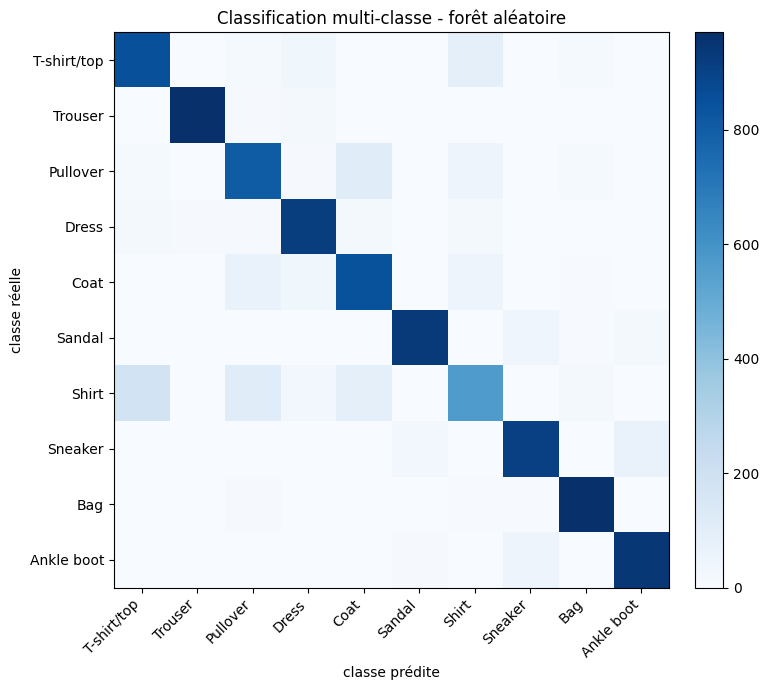

In [16]:
ut.plot_confusion_matrix(confusion_multi, "Classification multi-classe - forêt aléatoire")
plt.show()

**Lecture du graphe de matrice de confusion**  
Ce graphe représente le même tableau avec une échelle de bleu : une case en bleu clair correspond à peu d'exemples, tandis qu'une case en bleu foncé correspond à beaucoup d'exemples. La diagonale foncée montre les bonnes prédictions. Les cases foncées en dehors de la diagonale indiquent les confusions importantes.

Le graphe met visuellement en évidence les mêmes résultats que le tableau : les classes bien séparées ont une forte diagonale et peu de cases foncées ailleurs, comme `Trouser` ou `Bag`. Les vêtements du haut produisent davantage d'erreurs croisées, surtout autour de `T-shirt/top`, `Pullover`, `Coat` et `Shirt`.

In [17]:
# Repère les indices des images mal classées.
wrong = np.where(y_pred != y_test)[0]

# Crée un tableau croisé qui compte les confusions entre vraies classes et classes prédites.
confusions = pd.crosstab(
    # Classes réelles uniquement pour les images mal classées.
    pd.Series(y_test[wrong], name="classe_réelle"),

    # Classes prédites uniquement pour les images mal classées.
    pd.Series(y_pred[wrong], name="classe_prédite"),
)

# Affiche le nombre total d'erreurs sur le jeu de test.
print("Nombre d'erreurs :", len(wrong), "sur", len(y_test))

# Transforme le tableau en série, trie les erreurs les plus fréquentes, puis affiche les 10 confusions les plus nombreuses.
display(confusions.stack().sort_values(ascending=False).head(10).rename("nb_erreurs"))

Nombre d'erreurs : 1300 sur 10000


classe_réelle  classe_prédite
6              0                 179
2              4                 113
6              2                 112
               4                  90
0              6                  85
4              2                  67
7              9                  66
4              6                  48
2              6                  47
9              7                  46
Name: nb_erreurs, dtype: int64

**Lecture du tableau des erreurs les plus fréquentes**  
Ce tableau classe les erreurs hors diagonale de la matrice de confusion par nombre d'occurrences. La première valeur du couple est la vraie classe, la seconde est la classe prédite.

La confusion la plus fréquente est `6 -> 0` : 179 images de vrais `Shirt` sont prédites comme `T-shirt/top`. Les erreurs `2 -> 4` et `4 -> 2` montrent la confusion entre `Pullover` et `Coat`. Les erreurs `6 -> 2` et `6 -> 4` montrent que `Shirt` est aussi confondu avec `Pullover` et `Coat`. Au total, le modèle fait 1300 erreurs sur 10000 images de test, ce qui correspond à une accuracy de `0.8700`.

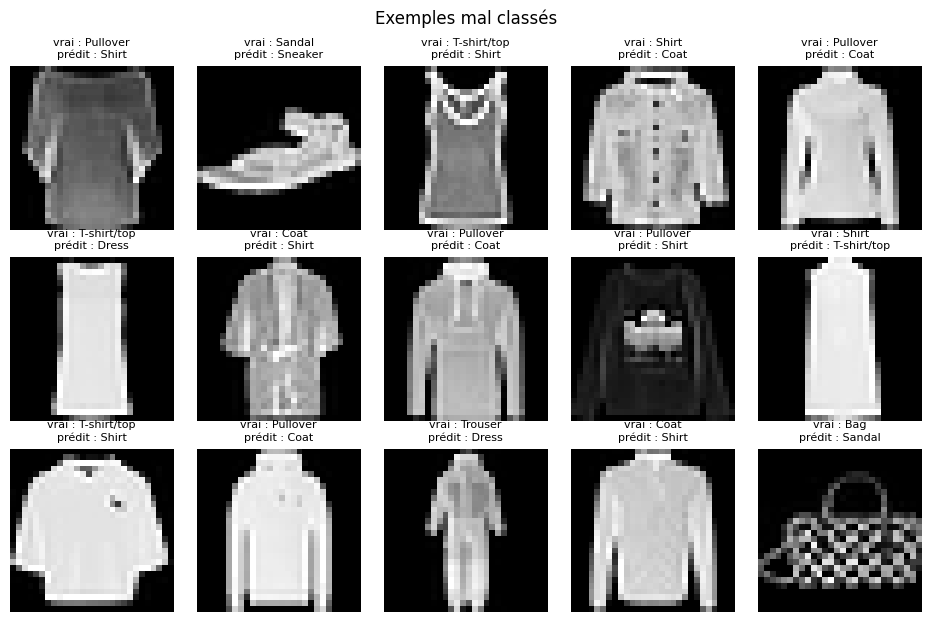

In [18]:
# Sélectionne les 15 premiers exemples mal classés.
indices = wrong[:15]

# Fixe le nombre de colonnes de la grille d'affichage.
n_cols = 5

# Calcule le nombre de lignes nécessaires pour afficher tous les exemples.
n_rows = int(np.ceil(len(indices) / n_cols))

# Crée la figure et les zones de dessin.
fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.9 * n_cols, 2.1 * n_rows))

# Transforme axes en tableau simple pour parcourir facilement chaque case.
axes = np.asarray(axes).reshape(-1)

# Parcourt chaque case de la grille avec l'indice d'une image mal classée.
for ax, idx in zip(axes, indices):
    # Récupère le nom de la vraie classe.
    vraie_classe = ut.CLASS_NAMES[int(y_test[idx])]

    # Récupère le nom de la classe prédite par le modèle.
    classe_predite = ut.CLASS_NAMES[int(y_pred[idx])]

    # Affiche l'image Fashion-MNIST en 28 x 28 pixels.
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray")

    # Ajoute le vrai label et le label prédit au-dessus de l'image.
    ax.set_title(f"vrai : {vraie_classe}\nprédit : {classe_predite}", fontsize=8)

    # Masque les axes pour garder seulement l'image et le titre.
    ax.axis("off")
# Masque les cases vides si la grille contient plus de cases que d'images.
for ax in axes[len(indices):]:
    ax.axis("off")

# Ajoute un titre général à la figure.
fig.suptitle("Exemples mal classés")

# Ajuste automatiquement les espacements pour éviter les chevauchements.
fig.tight_layout()

# Affiche la figure dans le notebook.
plt.show()

**Lecture du graphe des exemples mal classés**  
Chaque vignette montre une image que le modèle n'a pas correctement classée. Le titre indique la vraie classe et la classe prédite. Ces exemples permettent de comprendre concrètement les erreurs du modèle.

On retrouve surtout des images dont la silhouette est ambiguë ou proche d'une autre catégorie. C'est cohérent avec les tableaux précédents : beaucoup d'erreurs concernent des hauts de vêtement, dont les formes se ressemblent fortement en basse résolution.

**Analyse multi-classe.** La forêt aléatoire est le meilleur compromis parmi les modèles testés : en validation croisée sur 5000 exemples, elle obtient environ `0.834`, devant la régression logistique par SGD (`0.802`), le kNN (`0.791`), le perceptron (`0.776`) et l'arbre seul (`0.721`). Le modèle final entraîné sur 20000 exemples atteint environ `0.870` sur le jeu de test officiel. Les principales confusions concernent les classes de vêtements supérieurs : `Shirt` confondu avec `T-shirt/top`, `Pullover` ou `Coat`, ainsi que `Pullover` et `Coat` entre eux. Les chaussures sont mieux séparées, sauf quelques confusions `Sneaker` / `Ankle boot`.

## 4. Apprentissage non-supervisé : réduction de dimension et k-moyennes

Pour le clustering, on travaille sur un échantillon stratifié de 2500 exemples. Une ACP à 50 composantes réduit le bruit et accélère les distances. On évalue ensuite plusieurs valeurs de `k` avec l'inertie, le score silhouette, l'ARI et la NMI par rapport aux vraies classes.

In [19]:
# Crée un échantillon équilibré de 2500 images pour le clustering.
X_cluster, y_cluster = ut.stratified_sample(X_train, y_train, 2500, RANDOM_STATE)

# Crée une PCA qui réduit les images à 50 composantes principales.
pca50 = PCA(n_components=50, random_state=RANDOM_STATE)

# Applique la PCA sur les images sélectionnées.
X_cluster_pca = pca50.fit_transform(X_cluster)

# Affiche la part totale de variance conservée par les 50 composantes.
print(f"Variance expliquée par 50 composantes : {pca50.explained_variance_ratio_.sum():.3f}")

# Évalue K-Means pour plusieurs nombres de groupes.
kmeans_scores = clust.evaluate_kmeans_range(
    # Données réduites par PCA utilisées pour le clustering.
    X_cluster_pca,

    # Vraies classes utilisées seulement pour évaluer les groupes obtenus.
    y_cluster,

    # Nombres de groupes testés.
    k_values=[5, 10, 15, 20],

    # Graine aléatoire pour obtenir des résultats reproductibles.
    random_state=RANDOM_STATE,
)

# Affiche les scores ARI, NMI et inertie pour chaque valeur de k.
display(kmeans_scores)

Variance expliquée par 50 composantes : 0.866


,k,inertie,silhouette,ari,nmi
0,5,74520.828125,0.198870,0.283769,0.423457
1,10,56634.953125,0.198971,0.384676,0.535542
2,15,48314.027344,0.174306,0.373301,0.547470
3,20,43430.398438,0.161890,0.326317,0.537874


**Lecture du tableau d'évaluation de k-means**  
Chaque ligne correspond à une valeur de `k`, c'est-à-dire au nombre de clusters demandés. `inertie` mesure la compacité des clusters : plus elle est faible, plus les points sont proches de leur centre. `silhouette` mesure la séparation des clusters. `ari` et `nmi` comparent les clusters aux vraies classes.

L'inertie diminue quand `k` augmente, ce qui est attendu. Le meilleur compromis est ici `k=10`, car il garde une silhouette proche du maximum et donne le meilleur ARI (`0.385`) avec une NMI correcte (`0.536`). `k=15` améliore légèrement la NMI, mais baisse l'ARI et la silhouette.

In [20]:
# Crée un modèle K-Means avec 10 groupes, comme les 10 classes Fashion-MNIST.
kmeans10 = KMeans(n_clusters=10, n_init=10, random_state=RANDOM_STATE)

# Entraîne K-Means sur les données réduites par PCA et attribue un groupe à chaque image.
cluster_labels = kmeans10.fit_predict(X_cluster_pca)

# Crée un tableau qui compare les groupes trouvés avec les vraies classes.
cluster_table = clust.cluster_label_table(
    # Groupes attribués par K-Means.
    cluster_labels,

    # Vraies classes des images, utilisées seulement pour analyser les groupes.
    y_cluster,
)

# Affiche le tableau de correspondance entre groupes et classes.
display(cluster_table)

,0,1,2,3,4,5,6,7,8,9,classe_majoritaire,pureté
cluster,,,,,,,,,,,,
0,1,0,1,0,1,1,0,0,106,0,8,0.963636
1,56,3,74,20,41,0,92,0,6,0,6,0.315068
2,23,6,16,14,10,161,23,28,20,11,5,0.516026
3,8,224,0,133,10,0,5,0,3,0,1,0.584856
4,130,0,3,1,1,0,22,0,0,0,0,0.828025
5,0,0,0,0,0,70,0,207,5,29,7,0.665595
6,0,0,0,0,0,17,0,15,1,207,9,0.862500
7,1,0,2,0,0,1,1,0,98,1,8,0.942308
8,6,3,149,1,142,0,77,0,11,1,2,0.382051


**Lecture du tableau de composition des clusters k-means**  
Chaque ligne correspond à un cluster trouvé par k-means. Les colonnes `0` à `9` indiquent combien d'images de chaque vraie classe se trouvent dans ce cluster. `classe_majoritaire` donne la classe la plus présente, et `pureté` indique la proportion de cette classe majoritaire.

Les clusters associés à `Bag` ou à certaines chaussures sont assez purs. En revanche, plusieurs clusters mélangent fortement les hauts de vêtement : `T-shirt/top`, `Pullover`, `Coat` et `Shirt`. K-means retrouve donc des familles visuelles, mais pas parfaitement les 10 classes officielles.

In [21]:
print("ARI k=10:", adjusted_rand_score(y_cluster, cluster_labels))
print("NMI k=10:", normalized_mutual_info_score(y_cluster, cluster_labels))

ARI k=10: 0.38467623772356346
NMI k=10: 0.5355422065097504


**Lecture des scores ARI et NMI pour k-means**  
L'ARI et la NMI comparent les clusters obtenus avec les vraies classes. Une valeur proche de `1` signifie une très bonne correspondance, tandis qu'une valeur proche de `0` signifie une faible correspondance.

Ici, l'ARI est autour de `0.385` et la NMI autour de `0.536`. Les scores sont donc intermédiaires : k-means capture une partie de la structure des données, mais il ne retrouve pas parfaitement les labels.

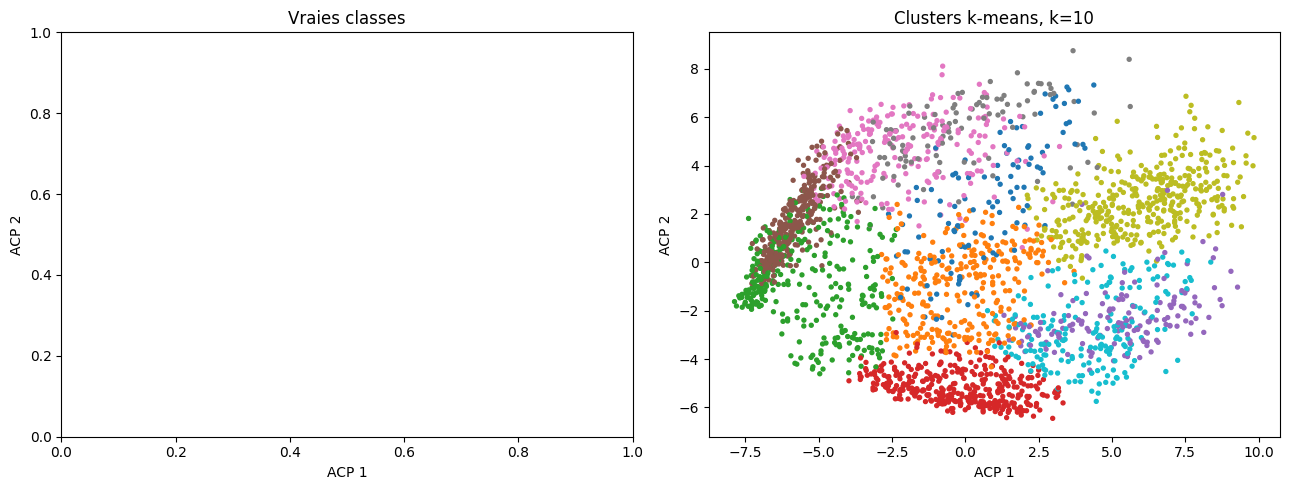

In [22]:
# Visualisation 2D des clusters obtenus par k-moyennes.

# Crée une PCA qui réduit les images à 2 composantes principales.
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)

# Applique la PCA pour obtenir des coordonnées en 2D.
X_cluster_2d = pca2.fit_transform(X_cluster)

# Crée une figure avec deux graphes côte à côte.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ajoute le titre du premier graphe.
axes[0].set_title("Vraies classes")

# Affiche les mêmes points colorés selon le cluster trouvé par K-Means.
axes[1].scatter(X_cluster_2d[:, 0], X_cluster_2d[:, 1], c=cluster_labels, cmap="tab10", s=8)

# Ajoute le titre du second graphe.
axes[1].set_title("Clusters k-means, k=10")

# Ajoute les noms des axes sur les deux graphes.
for ax in axes:
    # Axe horizontal : première composante principale.
    ax.set_xlabel("ACP 1")

    # Axe vertical : deuxième composante principale.
    ax.set_ylabel("ACP 2")

# Ajuste les espacements pour éviter les chevauchements.
fig.tight_layout()

# Affiche les deux graphes dans le notebook.
plt.show()

**Lecture de la visualisation 2D des clusters**  
Le graphe de gauche colore les points avec les vraies classes. Le graphe de droite colore les mêmes points avec les clusters trouvés par k-means. Les deux graphes utilisent une projection ACP en deux dimensions, donc ils résument les images avec seulement deux axes.

Certaines zones sont assez cohérentes entre vraies classes et clusters, notamment pour les catégories visuellement distinctes. En revanche, plusieurs régions se recouvrent, surtout pour les vêtements du haut. Le clustering retrouve des groupes utiles, mais pas une séparation parfaite des 10 classes.

## 5. Clustering hiérarchique

Le clustering hiérarchique est plus coûteux. On l'applique donc sur 500 exemples, après ACP à 20 composantes, puis on coupe le dendrogramme en 10 groupes.

In [23]:
# Crée un petit échantillon équilibré de 500 images pour le clustering hiérarchique.
X_hier, y_hier = ut.stratified_sample(X_train, y_train, 500, RANDOM_STATE)

# Réduit les images à 20 composantes principales avec une PCA.
X_hier_pca = PCA(n_components=20, random_state=RANDOM_STATE).fit_transform(X_hier)

# Calcule la matrice de liaison pour construire le dendrogramme.
Z = linkage(X_hier_pca, method="ward")

# Coupe l'arbre hiérarchique pour obtenir 10 groupes.
hier_labels = fcluster(Z, t=10, criterion="maxclust")

# Compare les groupes obtenus avec les vraies classes grâce au score ARI.
print("ARI hiérarchique :", adjusted_rand_score(y_hier, hier_labels))

# Compare les groupes obtenus avec les vraies classes grâce au score NMI.
print("NMI hiérarchique :", normalized_mutual_info_score(y_hier, hier_labels))

ARI hiérarchique : 0.4304627057142302
NMI hiérarchique : 0.6108869220297268


**Lecture des scores du clustering hiérarchique**  
Le clustering hiérarchique est évalué avec les mêmes mesures que k-means : ARI et NMI. Ces scores comparent les groupes trouvés avec les vraies classes, sans que les labels soient utilisés pour construire les groupes.

On obtient une NMI d'environ `0.611` et une ARI d'environ `0.430`, ce qui est meilleur que k-means dans cette expérience. En revanche, cette méthode est plus coûteuse, donc elle est appliquée sur seulement 500 exemples.

In [24]:
hier_cluster_table = clust.cluster_label_table(hier_labels, y_hier)
display(hier_cluster_table)

,0,1,2,3,4,5,6,7,8,9,classe_majoritaire,pureté
cluster,,,,,,,,,,,,
1,0,0,0,0,0,0,2,0,27,0,8,0.931034
2,0,0,0,0,0,0,0,3,0,38,9,0.926829
3,0,0,0,0,0,5,0,18,0,8,7,0.580645
4,0,0,0,0,0,43,0,29,1,3,5,0.565789
5,0,0,0,0,0,0,0,0,20,0,8,1.000000
6,6,1,15,2,11,2,14,0,1,1,2,0.283019
7,1,1,35,4,33,0,15,0,0,0,2,0.393258
8,0,47,0,21,1,0,1,0,1,0,1,0.661972
9,4,1,0,20,5,0,11,0,0,0,3,0.487805


**Lecture du tableau de composition des clusters hiérarchiques**  
Chaque ligne correspond à un groupe obtenu après découpe du dendrogramme en 10 clusters. Les colonnes `0` à `9` donnent le nombre d'images de chaque vraie classe dans le cluster. `classe_majoritaire` indique la classe dominante, et `pureté` mesure la proportion de cette classe.

Certains clusters sont très purs, par exemple des groupes dominés par `Bag` ou `Ankle boot`. D'autres mélangent plusieurs classes proches, surtout les vêtements du haut. Le clustering hiérarchique produit donc des groupes interprétables, mais il garde les mêmes difficultés sur les classes visuellement proches.

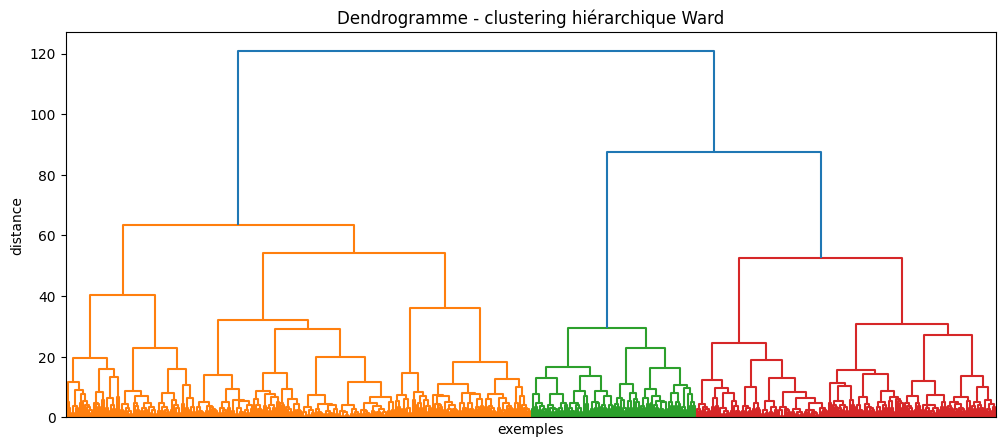

In [25]:
# Crée une nouvelle figure pour afficher le dendrogramme.
plt.figure(figsize=(12, 5))

# Trace le dendrogramme à partir de la matrice de liaison Z.
dendrogram(
    # Matrice de liaison calculée avec la méthode Ward.
    Z,

    # Masque les labels pour garder un affichage lisible.
    no_labels=True,

    # Ne fixe pas de seuil de couleur particulier.
    color_threshold=None,
)
# Ajoute le titre du graphe.
plt.title("Dendrogramme - clustering hiérarchique Ward")

# Nomme l'axe horizontal : chaque position correspond à un exemple.
plt.xlabel("exemples")

# Nomme l'axe vertical : hauteur de fusion entre groupes.
plt.ylabel("distance")

# Affiche le dendrogramme dans le notebook.
plt.show()

**Lecture du dendrogramme**  
Le dendrogramme représente l'ordre dans lequel les exemples ou groupes d'exemples sont fusionnés. Plus une fusion se produit haut dans le graphe, plus les groupes fusionnés sont éloignés. Les fusions basses correspondent à des exemples très similaires.

La coupe en 10 clusters force une comparaison avec les 10 classes Fashion-MNIST, mais la structure hiérarchique montre que les données ne sont pas séparées en 10 blocs parfaitement distincts.

**Analyse non-supervisée.** Avec k-means, `k=10` donne le meilleur compromis dans ces essais : silhouette proche de `0.199`, ARI proche de `0.385` et NMI proche de `0.536`. Les clusters ne correspondent donc pas parfaitement aux 10 labels, mais ils capturent des familles visuelles : sacs, chaussures et pantalons ressortent mieux que les hauts. Le clustering hiérarchique sur 500 exemples donne une NMI plus élevée (`0.611`) et une ARI proche de `0.430`, mais il est moins scalable sur tout le jeu de données.

## 6. Bilan

Les expériences confirment que Fashion-MNIST est plus difficile que MNIST classique : les classes visuellement proches sont les principales sources d'erreurs. En supervisé, la forêt aléatoire domine les modèles simples testés et atteint environ `87%` d'accuracy multi-classe sur le test officiel avec seulement 20000 exemples d'apprentissage. En non-supervisé, les groupes trouvés recouvrent partiellement les classes réelles, surtout pour les catégories visuellement très distinctes, mais les vêtements du haut restent mélangés.

Pour améliorer les résultats, les pistes naturelles seraient d'utiliser toute la base d'entraînement pour le modèle final, d'optimiser les hyper-paramètres et d'ajouter des représentations plus adaptées aux images, par exemple des descripteurs ou un modèle convolutionnel.